# BioSieve integration — live partitioning, provenance and fold diagnostics


## Goal
Exercise the canonical partition boundary. If BioSieve is installed, `mlcore` delegates partition generation to BioSieve and preserves provenance. If the optional dependency is absent, this executable documentation uses a clearly labeled pre-partitioned fallback; **there is no internal mlcore fallback splitter**.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from mlcore import validate
from mlcore.datasets import DatasetBundle, PartitionPlan, BioSievePartitionConfig
from mlcore.exceptions import OptionalDependencyError


In [2]:
n_samples=120 if DEMO_TEST else 300
X,y=make_classification(n_samples=n_samples,n_features=11,n_informative=7,weights=[.65,.35],class_sep=1.0,random_state=71)
ids=[f"bio_{i:04d}" for i in range(len(y))]
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"f{i}" for i in range(X.shape[1])])
LIVE_BIOSIEVE=False
try:
    result=validate(dataset=dataset,algorithm="logistic_regression",
                    partitioning=BioSievePartitionConfig(strategy="stratified_kfold",params={"n_splits":5,"seed":42}),
                    metrics=("mcc","balanced_accuracy","f1","roc_auc","pr_auc"),random_state=42)
    LIVE_BIOSIEVE=True
except OptionalDependencyError:
    plan=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=balanced_fold_labels(y,5),
        dataset_fingerprint=dataset.fingerprint,metadata={"source":"demo_prepartitioned_fallback","strategy":"stratified_like_5fold"})
    result=validate(dataset=dataset,algorithm="logistic_regression",partition_plan=plan,
                    metrics=("mcc","balanced_accuracy","f1","roc_auc","pr_auc"),random_state=42)
print("Live BioSieve:",LIVE_BIOSIEVE)
print("Partition metadata:",result.partition_plan.metadata)


Live BioSieve: True
Partition metadata: {'source': 'biosieve', 'biosieve_version': '0.1.2', 'strategy': 'stratified_kfold', 'requested_params': {'n_splits': 5, 'seed': 42}}


In [3]:
fold_rows=[]
for fold in result.folds:
    eval_y=dataset.subset(fold.evaluation_ids).y
    fold_rows.append({"fold":fold.split_name,"n_eval":len(eval_y),"positive_rate":float(np.mean(eval_y)),**fold.evaluation.metrics})
fold_df=pd.DataFrame(fold_rows)
fold_df


,fold,n_eval,positive_rate,balanced_accuracy,f1,mcc,roc_auc,pr_auc
0,fold_0,60,0.366667,0.655502,0.500000,0.402147,0.747608,0.699629
1,fold_1,60,0.366667,0.716507,0.634146,0.448577,0.769139,0.634776
2,fold_2,60,0.366667,0.663876,0.577778,0.324850,0.742823,0.706673
3,fold_3,60,0.350000,0.725275,0.625000,0.555380,0.927961,0.879888
4,fold_4,60,0.350000,0.719780,0.634146,0.444750,0.819292,0.632026


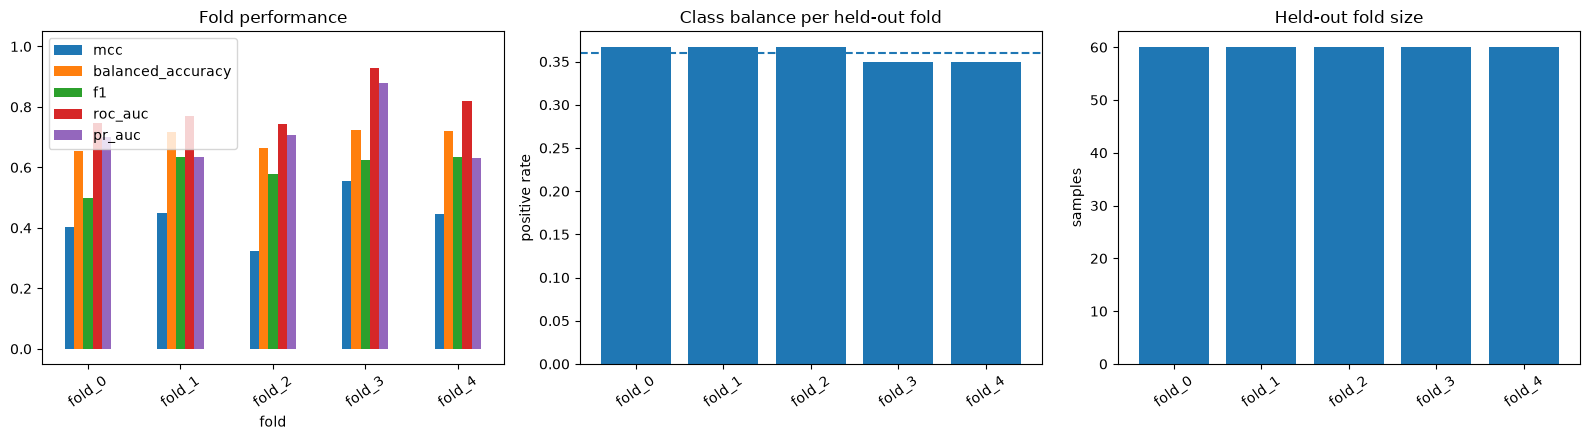

In [4]:
fig,axes=plt.subplots(1,3,figsize=(16,4.5))
fold_df.set_index("fold")[["mcc","balanced_accuracy","f1","roc_auc","pr_auc"]].plot.bar(ax=axes[0]); axes[0].set_ylim(-.05,1.05); axes[0].set_title("Fold performance")
axes[1].bar(fold_df.fold,fold_df.positive_rate); axes[1].axhline(np.mean(y),linestyle="--"); axes[1].set(title="Class balance per held-out fold",ylabel="positive rate")
axes[2].bar(fold_df.fold,fold_df.n_eval); axes[2].set(title="Held-out fold size",ylabel="samples")
for ax in axes: ax.tick_params(axis="x",rotation=35)
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
DEMO_CHECKS={
    "five_splits":result.n_splits==5,
    "complete_oof":result.metadata["oof_complete"] is True,
    "source_explicit":result.partition_plan.metadata.get("source") in {"biosieve","demo_prepartitioned_fallback"},
    "fold_diagnostics":len(fold_df)==5,
    "finite_metrics":np.isfinite(fold_df[["mcc","balanced_accuracy","f1","roc_auc","pr_auc"]].to_numpy()).all(),
    "figure_created":FIGURE_COUNT==1,
}
if LIVE_BIOSIEVE: DEMO_CHECKS["live_source_is_biosieve"]=result.partition_plan.metadata.get("source")=="biosieve"
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'five_splits': True,
 'complete_oof': True,
 'source_explicit': True,
 'fold_diagnostics': True,
 'finite_metrics': np.True_,
 'figure_created': True,
 'live_source_is_biosieve': True}